In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import numpy as np


C:\Users\matts\OneDrive\Matthew\PersonalPythonProjects\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "MoritzLaurer/DeBERTa-v3-base-mnli"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

dataset = load_dataset("nyu-mll/glue", "mnli", split="validation_matched")
correct, incorrect = [], []

exe_baseline = True
if exe_baseline:
    y_true, y_pred = [], []
    for example in dataset:
        p_ids = tokenizer.encode(example["premise"], add_special_tokens=False)
        h_ids = tokenizer.encode(example["hypothesis"], add_special_tokens=False)

        # create model input sequence. Just start with a CLS token ( [1] ) and append the premise and hypothesis separated by
        # SEP tokens ( [2] )
        full_input_ids = [1] + p_ids + [2] + h_ids + [2]

        # tell the model which part of the input is the premise or hypothesis. 0 means premise, 1 means hypothesis
        token_type_ids = [0] * (len(p_ids) + 2) + [1] * (len(h_ids) + 1)

        # there is no attention mask because all tokens are being attended to by [1].
        # If any elem index had [0] then it would be masked.
        inputs = {
            "input_ids": torch.tensor([full_input_ids]).to(device),
            "token_type_ids": torch.tensor([token_type_ids]).to(device),
            "attention_mask": torch.tensor([[1] * len(full_input_ids)]).to(device)
        }

        with torch.no_grad():
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=-1).item()
            y_pred.append(pred)

        true = example["label"]
        y_true.append(true)

        if pred == true:
            correct.append(example)
        else:
            incorrect.append(example)

    print(f"Corrected Accuracy: {accuracy_score(y_true, y_pred):.4f}")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 671.77it/s, Materializing param=pooler.dense.weight]                                       
DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Corrected Accuracy: 0.8997


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 807.57it/s, Materializing param=pooler.dense.weight]                                       
DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


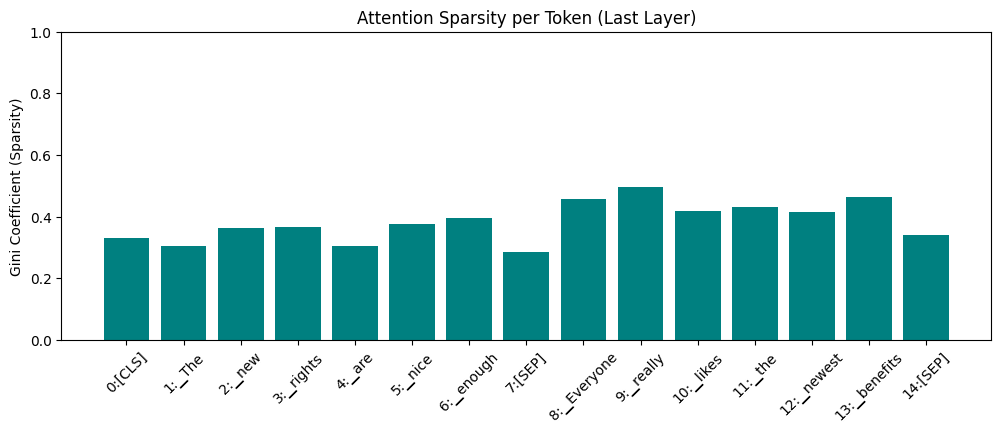

In [3]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    output_attentions=True
).to(device)

index = 0
p_ids = tokenizer.encode(dataset[index]['premise'], add_special_tokens=False)
h_ids = tokenizer.encode(dataset[index]['hypothesis'], add_special_tokens=False)
full_input_ids = [1] + p_ids + [2] + h_ids + [2]
tokens = tokenizer.convert_ids_to_tokens(full_input_ids)

inputs = {
    "input_ids": torch.tensor([full_input_ids]).to(device),
    "token_type_ids": torch.tensor([[0] * (len(p_ids) + 2) + [1] * (len(h_ids) + 1)]).to(device),
    "attention_mask": torch.tensor([[1] * len(full_input_ids)]).to(device)
}

with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions

last_layer_attn = attentions[-1][0].cpu().mean(dim=0).numpy()



def calculate_gini(array):
    """Calculate the Gini coefficient of a 1D numpy array."""
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


gini_scores = [calculate_gini(row) for row in last_layer_attn]
gini_tokens = [f"{ind}:" + tok for ind, tok in enumerate(tokens)]
plt.figure(figsize=(12, 4))
plt.bar(gini_tokens, gini_scores, color='teal')
plt.xticks(rotation=45)
plt.ylabel("Gini Coefficient (Sparsity)")
plt.title("Attention Sparsity per Token (Last Layer)")
plt.ylim(0, 1)
plt.show()

Plot above shows how concentrated that query tokens attention was over all keys (lower means spread focus out more, higher means focus spread out less)

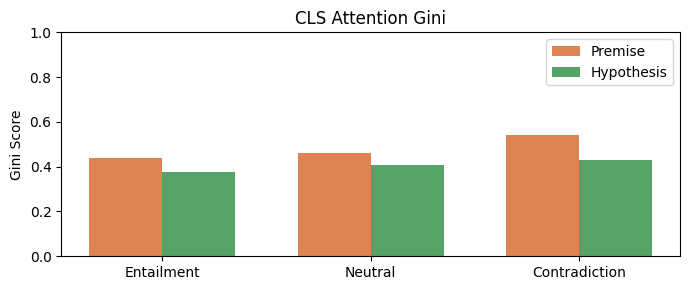

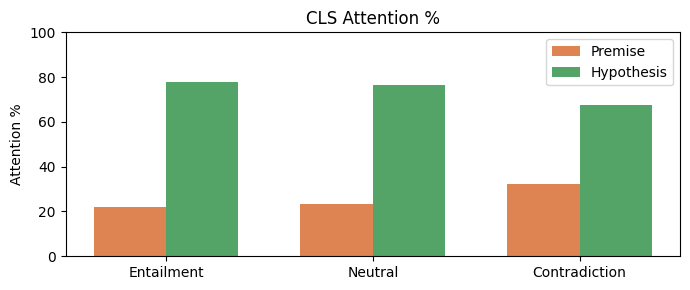

In [5]:
import numpy as np

# WE ONLY WANT CLS row

def calculate_gini(array):
    """Calculate the Gini coefficient of a 1D numpy array."""
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


entailment_dataset = dataset.filter(lambda x: x["label"] == 0)
neutral_dataset = dataset.filter(lambda x: x["label"] == 1)
contradiction_dataset = dataset.filter(lambda x: x["label"] == 2)

results = {}

for ds, label in [(entailment_dataset, "Entailment"), (neutral_dataset, "Neutral"), (contradiction_dataset, "Contradiction")]:
    premise_ginis = []
    hypothesis_ginis = []

    premise_percents = []
    hypothesis_percents = []

    for i in range(len(ds)):
        p_ids = tokenizer.encode(ds[i]['premise'], add_special_tokens=False)
        h_ids = tokenizer.encode(ds[i]['hypothesis'], add_special_tokens=False)

        full_input_ids = [1] + p_ids + [2] + h_ids + [2]

        inputs = {
            "input_ids": torch.tensor([full_input_ids]).to(device),
            "token_type_ids": torch.tensor([[0]*(len(p_ids)+2) + [1]*(len(h_ids)+1)]).to(device),
            "attention_mask": torch.tensor([[1]*len(full_input_ids)]).to(device)
        }

        with torch.no_grad():
            outputs = model(**inputs)
            attentions = outputs.attentions

        last_layer_attn = attentions[-1][0].cpu().mean(dim=0).numpy()
        cls_attn = last_layer_attn[0, :]

        premise_attn = cls_attn[1:1+len(p_ids)]
        hypothesis_attn = cls_attn[2+len(p_ids):2+len(p_ids)+len(h_ids)]

        premise_density = premise_attn.sum()
        hypothesis_density = hypothesis_attn.sum()
        total_density = premise_density + hypothesis_density

        premise_density_percent = premise_density / total_density * 100
        hypothesis_density_percent = hypothesis_density / total_density * 100

        premise_gini = calculate_gini(premise_attn)
        hypothesis_gini = calculate_gini(hypothesis_attn)

        premise_ginis.append(premise_gini)
        hypothesis_ginis.append(hypothesis_gini)

        premise_percents.append(premise_density_percent)
        hypothesis_percents.append(hypothesis_density_percent)

    results[label] = {
        "premise_gini": np.mean(premise_ginis),
        "hypothesis_gini": np.mean(hypothesis_ginis),
        "premise_percent": np.mean(premise_percents),
        "hypothesis_percent": np.mean(hypothesis_percents),
    }


labels = ["Entailment", "Neutral", "Contradiction"]
x = np.arange(len(labels))
width = 0.35

premise_ginis = [results[label]["premise_gini"] for label in labels]
hypothesis_ginis = [results[label]["hypothesis_gini"] for label in labels]

premise_percents = [results[label]["premise_percent"] for label in labels]
hypothesis_percents = [results[label]["hypothesis_percent"] for label in labels]

fig, axes = plt.subplots(1, 1, figsize=(7, 3))
axes.bar(x - width/2, premise_ginis, width, label="Premise", color="#DD8452")
axes.bar(x + width/2, hypothesis_ginis, width, label="Hypothesis", color="#55A467")
axes.set_title("CLS Attention Gini")
axes.set_ylabel("Gini Score")
axes.set_xticks(x)
axes.set_xticklabels(labels)
axes.set_ylim(0, 1)
axes.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(7, 3))
axes.bar(x - width/2, premise_percents, width, label="Premise", color="#DD8452")
axes.bar(x + width/2, hypothesis_percents, width, label="Hypothesis", color="#55A467")
axes.set_title("CLS Attention %")
axes.set_ylabel("Attention %")
axes.set_xticks(x)
axes.set_xticklabels(labels)
axes.set_ylim(0, 100)
axes.legend()

plt.tight_layout()
plt.show()

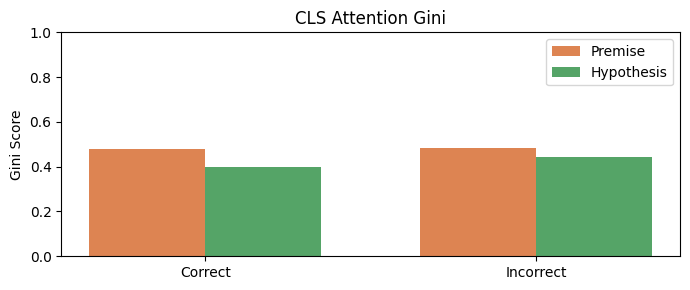

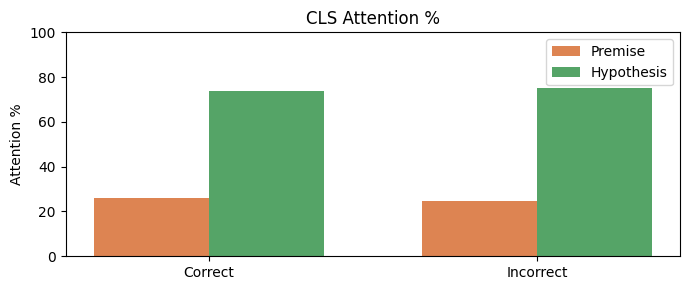

In [7]:
import numpy as np

# WE ONLY WANT CLS row

def calculate_gini(array):
    """Calculate the Gini coefficient of a 1D numpy array."""
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


entailment_dataset = dataset.filter(lambda x: x["label"] == 0)
neutral_dataset = dataset.filter(lambda x: x["label"] == 1)
contradiction_dataset = dataset.filter(lambda x: x["label"] == 2)

results = {}

for ds, label in [(correct, "Correct"), (incorrect, "Incorrect")]:
    premise_ginis = []
    hypothesis_ginis = []

    premise_percents = []
    hypothesis_percents = []

    for i in range(len(ds)):
        p_ids = tokenizer.encode(ds[i]['premise'], add_special_tokens=False)
        h_ids = tokenizer.encode(ds[i]['hypothesis'], add_special_tokens=False)

        full_input_ids = [1] + p_ids + [2] + h_ids + [2]

        inputs = {
            "input_ids": torch.tensor([full_input_ids]).to(device),
            "token_type_ids": torch.tensor([[0]*(len(p_ids)+2) + [1]*(len(h_ids)+1)]).to(device),
            "attention_mask": torch.tensor([[1]*len(full_input_ids)]).to(device)
        }

        with torch.no_grad():
            outputs = model(**inputs)
            attentions = outputs.attentions

        last_layer_attn = attentions[-1][0].cpu().mean(dim=0).numpy()
        cls_attn = last_layer_attn[0, :]

        premise_attn = cls_attn[1:1+len(p_ids)]
        hypothesis_attn = cls_attn[2+len(p_ids):2+len(p_ids)+len(h_ids)]

        premise_density = premise_attn.sum()
        hypothesis_density = hypothesis_attn.sum()
        total_density = premise_density + hypothesis_density

        premise_density_percent = premise_density / total_density * 100
        hypothesis_density_percent = hypothesis_density / total_density * 100

        premise_gini = calculate_gini(premise_attn)
        hypothesis_gini = calculate_gini(hypothesis_attn)

        premise_ginis.append(premise_gini)
        hypothesis_ginis.append(hypothesis_gini)

        premise_percents.append(premise_density_percent)
        hypothesis_percents.append(hypothesis_density_percent)

    results[label] = {
        "premise_gini": np.mean(premise_ginis),
        "hypothesis_gini": np.mean(hypothesis_ginis),
        "premise_percent": np.mean(premise_percents),
        "hypothesis_percent": np.mean(hypothesis_percents),
    }


labels = ["Correct", "Incorrect"]
x = np.arange(len(labels))
width = 0.35

premise_ginis = [results[label]["premise_gini"] for label in labels]
hypothesis_ginis = [results[label]["hypothesis_gini"] for label in labels]

premise_percents = [results[label]["premise_percent"] for label in labels]
hypothesis_percents = [results[label]["hypothesis_percent"] for label in labels]

fig, axes = plt.subplots(1, 1, figsize=(7, 3))
axes.bar(x - width/2, premise_ginis, width, label="Premise", color="#DD8452")
axes.bar(x + width/2, hypothesis_ginis, width, label="Hypothesis", color="#55A467")
axes.set_title("CLS Attention Gini")
axes.set_ylabel("Gini Score")
axes.set_xticks(x)
axes.set_xticklabels(labels)
axes.set_ylim(0, 1)
axes.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(7, 3))
axes.bar(x - width/2, premise_percents, width, label="Premise", color="#DD8452")
axes.bar(x + width/2, hypothesis_percents, width, label="Hypothesis", color="#55A467")
axes.set_title("CLS Attention %")
axes.set_ylabel("Attention %")
axes.set_xticks(x)
axes.set_xticklabels(labels)
axes.set_ylim(0, 100)
axes.legend()

plt.tight_layout()
plt.show()

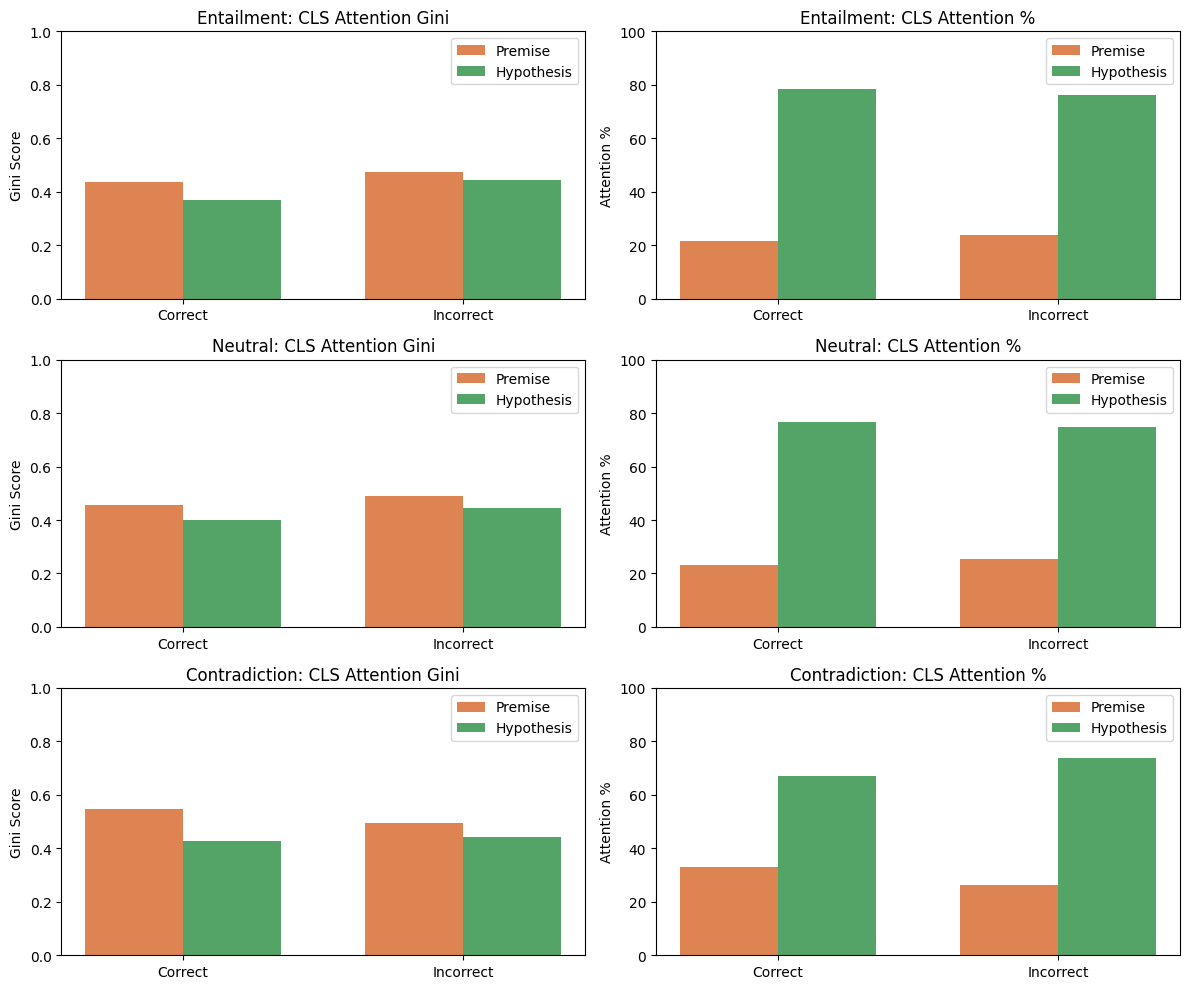

In [6]:
import numpy as np

# WE ONLY WANT CLS row

def calculate_gini(array):
    """Calculate the Gini coefficient of a 1D numpy array."""
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


results = {}

class_labels = [
    (0, "Entailment"),
    (1, "Neutral"),
    (2, "Contradiction")
]

for class_id, class_label in class_labels:
    results[class_label] = {}

    correct_class = [ex for ex in correct if ex["label"] == class_id]
    incorrect_class = [ex for ex in incorrect if ex["label"] == class_id]

    for ds, label in [(correct_class, "Correct"), (incorrect_class, "Incorrect")]:
        premise_ginis = []
        hypothesis_ginis = []

        premise_percents = []
        hypothesis_percents = []

        for i in range(len(ds)):
            p_ids = tokenizer.encode(ds[i]['premise'], add_special_tokens=False)
            h_ids = tokenizer.encode(ds[i]['hypothesis'], add_special_tokens=False)

            full_input_ids = [1] + p_ids + [2] + h_ids + [2]

            inputs = {
                "input_ids": torch.tensor([full_input_ids]).to(device),
                "token_type_ids": torch.tensor([[0]*(len(p_ids)+2) + [1]*(len(h_ids)+1)]).to(device),
                "attention_mask": torch.tensor([[1]*len(full_input_ids)]).to(device)
            }

            with torch.no_grad():
                outputs = model(**inputs)
                attentions = outputs.attentions

            last_layer_attn = attentions[-1][0].cpu().mean(dim=0).numpy()
            cls_attn = last_layer_attn[0, :]

            premise_attn = cls_attn[1:1+len(p_ids)]
            hypothesis_attn = cls_attn[2+len(p_ids):2+len(p_ids)+len(h_ids)]

            premise_density = premise_attn.sum()
            hypothesis_density = hypothesis_attn.sum()
            total_density = premise_density + hypothesis_density

            premise_density_percent = premise_density / total_density * 100
            hypothesis_density_percent = hypothesis_density / total_density * 100

            premise_gini = calculate_gini(premise_attn)
            hypothesis_gini = calculate_gini(hypothesis_attn)

            premise_ginis.append(premise_gini)
            hypothesis_ginis.append(hypothesis_gini)

            premise_percents.append(premise_density_percent)
            hypothesis_percents.append(hypothesis_density_percent)

        results[class_label][label] = {
            "premise_gini": np.mean(premise_ginis),
            "hypothesis_gini": np.mean(hypothesis_ginis),
            "premise_percent": np.mean(premise_percents),
            "hypothesis_percent": np.mean(hypothesis_percents),
        }


labels = ["Correct", "Incorrect"]
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for row, class_label in enumerate(["Entailment", "Neutral", "Contradiction"]):
    premise_ginis = [results[class_label][label]["premise_gini"] for label in labels]
    hypothesis_ginis = [results[class_label][label]["hypothesis_gini"] for label in labels]

    premise_percents = [results[class_label][label]["premise_percent"] for label in labels]
    hypothesis_percents = [results[class_label][label]["hypothesis_percent"] for label in labels]

    axes[row,0].bar(x - width/2, premise_ginis, width, label="Premise", color="#DD8452")
    axes[row,0].bar(x + width/2, hypothesis_ginis, width, label="Hypothesis", color="#55A467")
    axes[row,0].set_title(f"{class_label}: CLS Attention Gini")
    axes[row,0].set_ylabel("Gini Score")
    axes[row,0].set_xticks(x)
    axes[row,0].set_xticklabels(labels)
    axes[row,0].set_ylim(0, 1)
    axes[row,0].legend()

    axes[row,1].bar(x - width/2, premise_percents, width, label="Premise", color="#DD8452")
    axes[row,1].bar(x + width/2, hypothesis_percents, width, label="Hypothesis", color="#55A467")
    axes[row,1].set_title(f"{class_label}: CLS Attention %")
    axes[row,1].set_ylabel("Attention %")
    axes[row,1].set_xticks(x)
    axes[row,1].set_xticklabels(labels)
    axes[row,1].set_ylim(0, 100)
    axes[row,1].legend()

plt.tight_layout()
plt.show()